# Experiment 02 — Feature Scaling (2 → 4 → 6 → 8 Features)

**Research question:** Does increasing feature dimensionality improve VQC classification performance?

**Setup:** For each feature count, we run the same VQC architecture with 2 layers.
Additional qubits are added as features increase.  
Features are selected by hand (low-level physics variables from HIGGS).

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.metrics import roc_auc_score

from utils.data_utils import load_higgs, binary_accuracy

np.random.seed(42)

In [2]:
# Hyperparameters (held constant across all experiments)
N_LAYERS   = 2
N_EPOCHS   = 30
BATCH_SIZE = 32
LR         = 0.01
N_SAMPLES  = 5000

# HIGGS feature columns to use (0-indexed into data.iloc[:,1:])
# First 8 are the low-level detector variables
FEATURE_SETS = {
    2: [4, 6],
    4: [4, 6, 7, 8],
    6: [4, 6, 7, 8, 1, 2],
    8: [4, 6, 7, 8, 1, 2, 3, 5],
}

In [3]:
def build_circuit(n_features, n_layers):
    """Build and return a VQC circuit for n_features qubits."""
    dev = qml.device('default.qubit', wires=n_features)

    @qml.qnode(dev, interface='autograd')
    def circuit(weights, x):
        # State preparation
        for i in range(n_features):
            qml.RY(x[i], wires=i)
        # Model circuit
        for l in range(n_layers):
            for q in range(n_features):
                qml.Rot(weights[l, q, 0], weights[l, q, 1], weights[l, q, 2], wires=q)
            for q in range(n_features - 1):
                qml.CNOT(wires=[q, q + 1])
            if n_features > 1:
                qml.CNOT(wires=[n_features - 1, 0])
        return qml.expval(qml.PauliZ(0))

    return circuit


def train_vqc(circuit_fn, X_train, y_train, X_val, y_val,
              n_layers, n_features, n_epochs, batch_size, lr):
    weights = pnp.array(
        np.random.uniform(0, 2*np.pi, (n_layers, n_features, 3)),
        requires_grad=True
    )
    bias = pnp.array(0.0, requires_grad=True)
    opt = qml.AdamOptimizer(stepsize=lr)

    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        perm = np.random.permutation(len(X_train))
        Xs, ys = X_train[perm], y_train[perm]

        for start in range(0, len(Xs), batch_size):
            Xb = Xs[start:start+batch_size]
            yb = ys[start:start+batch_size].astype(float)

            def cost(w, b):
                preds = pnp.array([circuit_fn(w, x) + b for x in Xb])
                return pnp.mean((yb - preds) ** 2)

            weights, bias = opt.step(cost, weights, bias)

        # Epoch loss
        def full_loss(X, y):
            preds = pnp.array([circuit_fn(weights, x) + bias for x in X])
            return float(pnp.mean((y.astype(float) - preds) ** 2))

        train_losses.append(full_loss(X_train, y_train))
        val_losses.append(full_loss(X_val, y_val))

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{n_epochs} | '
                  f'train_loss={train_losses[-1]:.4f}, val_loss={val_losses[-1]:.4f}')

    return weights, bias, train_losses, val_losses

In [4]:
results = {}

for n_feat, feat_cols in FEATURE_SETS.items():
    print(f'\n{'='*50}')
    print(f'Running: {n_feat} features, columns={feat_cols}')

    X_train, X_val, X_test, y_train, y_val, y_test = load_higgs(
        path='../data/HIGGS.csv.gz',
        n_samples=N_SAMPLES,
        feature_indices=feat_cols,
        scale_range=(0, np.pi),
    )

    circuit_fn = build_circuit(n_feat, N_LAYERS)

    np.random.seed(42)
    weights, bias, tr_loss, vl_loss = train_vqc(
        circuit_fn, X_train, y_train, X_val, y_val,
        N_LAYERS, n_feat, N_EPOCHS, BATCH_SIZE, LR
    )

    # Final evaluation on test set
    test_raw = np.array([float(circuit_fn(weights, x) + bias) for x in X_test])
    test_acc = binary_accuracy(y_test, test_raw)
    y_test_01 = (y_test == 1).astype(int)
    test_score = (test_raw - test_raw.min()) / (test_raw.max() - test_raw.min() + 1e-8)
    test_auc = roc_auc_score(y_test_01, test_score)

    results[n_feat] = {
        'train_losses': tr_loss,
        'val_losses': vl_loss,
        'test_acc': test_acc,
        'test_auc': test_auc,
        'n_params': N_LAYERS * n_feat * 3 + 1,
    }
    print(f'  → Test acc: {test_acc:.4f} | Test AUC: {test_auc:.4f} | Params: {results[n_feat]["n_params"]}')


Running: 2 features, columns=[4, 6]
Dataset: 5000 samples | 2 features | train=3000, val=1000, test=1000
  Epoch 10/30 | train_loss=0.9832, val_loss=0.9812
  Epoch 20/30 | train_loss=0.9853, val_loss=0.9844
  Epoch 30/30 | train_loss=0.9830, val_loss=0.9809
  → Test acc: 0.5750 | Test AUC: 0.5709 | Params: 13

Running: 4 features, columns=[4, 6, 7, 8]
Dataset: 5000 samples | 2 features | train=3000, val=1000, test=1000
  Epoch 10/30 | train_loss=0.9832, val_loss=0.9846
  Epoch 20/30 | train_loss=0.9834, val_loss=0.9865
  Epoch 30/30 | train_loss=0.9807, val_loss=0.9837
  → Test acc: 0.5740 | Test AUC: 0.5496 | Params: 25

Running: 6 features, columns=[4, 6, 7, 8, 1, 2]
Dataset: 5000 samples | 2 features | train=3000, val=1000, test=1000
  Epoch 10/30 | train_loss=0.9724, val_loss=0.9820
  Epoch 20/30 | train_loss=0.9713, val_loss=0.9815
  Epoch 30/30 | train_loss=0.9719, val_loss=0.9846
  → Test acc: 0.5610 | Test AUC: 0.5289 | Params: 37

Running: 8 features, columns=[4, 6, 7, 8, 1, 

In [5]:
# --- Summary table ---
print('\nFeature Scaling Results')
print(f'{"Features":>10} {"Params":>8} {"Test Acc":>10} {"Test AUC":>10}')
print('-' * 42)
for nf, r in results.items():
    print(f'{nf:>10} {r["n_params"]:>8} {r["test_acc"]:>10.4f} {r["test_auc"]:>10.4f}')


Feature Scaling Results
  Features   Params   Test Acc   Test AUC
------------------------------------------
         2       13     0.5750     0.5709
         4       25     0.5740     0.5496
         6       37     0.5610     0.5289
         8       49     0.5620     0.5228


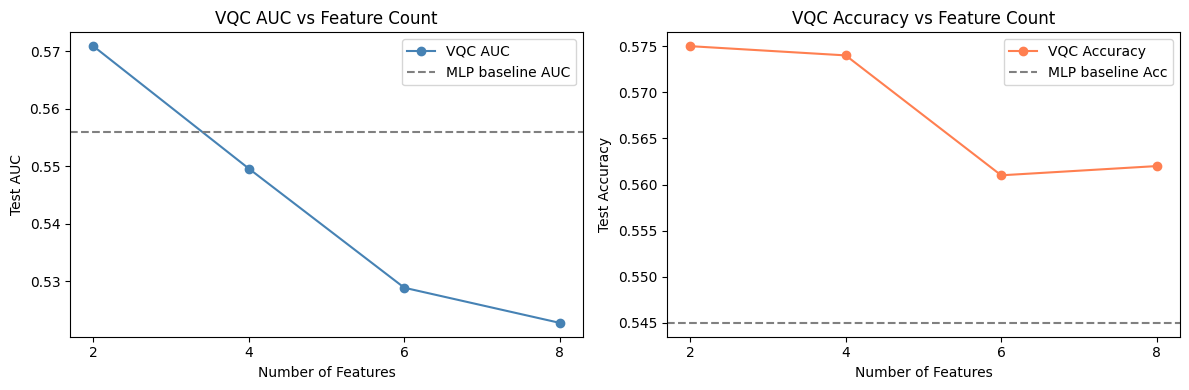

In [6]:
# --- Plot: AUC vs number of features ---
feat_counts = list(results.keys())
aucs = [results[f]['test_auc'] for f in feat_counts]
accs = [results[f]['test_acc'] for f in feat_counts]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(feat_counts, aucs, 'o-', color='steelblue', label='VQC AUC')
axes[0].axhline(0.556, color='gray', linestyle='--', label='MLP baseline AUC')
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('Test AUC')
axes[0].set_title('VQC AUC vs Feature Count')
axes[0].set_xticks(feat_counts)
axes[0].legend()

axes[1].plot(feat_counts, accs, 'o-', color='coral', label='VQC Accuracy')
axes[1].axhline(0.545, color='gray', linestyle='--', label='MLP baseline Acc')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('VQC Accuracy vs Feature Count')
axes[1].set_xticks(feat_counts)
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/02_feature_scaling.png', dpi=150)
plt.show()

## Observations

*(Fill in after running)*

- Does AUC increase monotonically with features?
- Is there a point of diminishing returns or degradation (barren plateau)?
- How does the VQC compare to the classical MLP at each feature count?